# <center>**Enhancing LEM-X Imaging with the IROS Reconstruction Pipeline**<center>

## <center>**Sky Reconstruction Efficiency**<center>

In [1]:
from pathlib import Path
from typing import Any, Callable

import numpy as np
from numpy.typing import NDArray
import astropy.units as u
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import WCSAxes
from regions import Regions, PixCoord, TextPixelRegion, RegionVisual

from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.io import simulation_files
import darksun as ds

from IROSrec.handle import config_dirpaths
import imgmaker as mgm

In [2]:
MASK_FITS: str = "mask_NTHT_20250725.fits"
UPS_X, UPS_Y = 2, 1

SKYFIELD: str = "GalacticCentre"
DATA_FITS: str = "galctr_rxte-sax_mask_050_1040x17_2-50keV_1ks"

RUN_ID: str = 'GC_rec_1ks_2-50keV'

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
# DATASET: str = "reconstructed"

In [3]:
MASK_PATH, SIMUL_DATA_PATH, SAVE_PATH = config_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    runID=RUN_ID,
)
OUT_RESULTS_PATH = mgm.config_savedata_to()

wfm: CodedMaskCamera = codedmask(MASK_PATH, UPS_X, UPS_Y)

filepaths: dict[str, dict[str, Path]] = simulation_files(SIMUL_DATA_PATH)
sdlA = ds.get_data(filepaths[ID_CAMERA_A]["reconstructed"])
catA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])
sdlB = ds.get_data(filepaths[ID_CAMERA_B]["reconstructed"])
catB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])

logA, logB = ds.load_database(f"{SAVE_PATH}/IROS_sources_db.fits")

cu_map = mgm.get_srcmap_for_unit(logA.log['ID'], logB.log['ID'])

# Loading data...
# Loading completed!


### <center>**Sky-field Decoding**<center>

In [4]:
from darksun.show import export_pltparams

def show_composed_skymap(
    image: NDArray,
    wcs: WCS,
    reg: Regions | None = None,
    ticks_spacing: int | float = 20,
    txt_offset: tuple[int, int] = (5, 20),
    txt_visual: dict[str, Any] | None = None,
    save_to: str | None = None,
    figsize: tuple[int | float, int | float] = (5, 5),
) -> None:
    """
    Plots the LEM-X Unit composed skymap with reconstructed sources from IROS.\n
    CFR w: [composed GalCentre](https://github.com/yuri-evangelista/CodedMasks/blob/main/mask_050_1040x17/Plot_IROS_Composed_Image.ipynb).
    """
    PLOTPARAMS = export_pltparams()
    PLOTPARAMS['ticklabel_fs'] = 6
    KWS = {
        'cmap': 'viridis', 'origin': 'lower', 'interpolation': 'none', 'norm': 'log',
    }

    fig = plt.figure(figsize=figsize, dpi=250)
    wcsax = WCSAxes(fig, 111, wcs=wcs)
    fig.add_axes(wcsax)

    # config ticks
    for crd in wcsax.coords:
        crd.set_ticklabel_visible(False)
        crd.set_ticks_visible(False)

    # confing `galactic` overlay
    overlay = wcsax.get_coords_overlay('galactic')
    overlay.grid(
        visible=True, color=PLOTPARAMS['grid_color'], linestyle=PLOTPARAMS['grid_ls'],
        linewidth=0.8 * PLOTPARAMS['grid_lw'], alpha=0.2,
    )
    axs_lbl = ('Galactic Longitude [deg]', 'Galactic Latitude [deg]')
    for lbl, ovl in zip(axs_lbl, overlay):
        ovl.set_axislabel(lbl, fontsize=1.1 * PLOTPARAMS['ticklabel_fs'], fontweight=PLOTPARAMS['label_fw'])
        ovl.set_ticklabel(fontsize=PLOTPARAMS['ticklabel_fs'], fontweight=PLOTPARAMS['label_fw'])
        ovl.set_major_formatter('d')
        ovl.set_ticks(spacing=ticks_spacing * u.degree)
        ovl.tick_params(which='both', direction='in', width=1.5, length=3 if 'major' else 2)
    
    img = wcsax.imshow(image, **KWS)
    cbar = fig.colorbar(
        img, ax=wcsax, location='bottom', shrink=0.5 * PLOTPARAMS['cbar_shrink'],
        pad=PLOTPARAMS[f'cbar_pad_right'],
    )
    cbar.ax.tick_params(labelsize=PLOTPARAMS['ticklabel_fs'])
    cbar.set_label(
        'SNR', fontsize=1.1 * PLOTPARAMS['ticklabel_fs'], fontweight=PLOTPARAMS['cbar_label_fw'],
    )

    # insert region info
    if reg is not None:
        txt_visual_ = txt_visual or {}
        visual = RegionVisual(txt_visual_)
        delta = PixCoord(*txt_offset)
        for src in reg:
            text = src.meta['text']
            pixel_region = src.to_pixel(wcs)
            pixel_region.plot(ax=wcsax)
            txt = TextPixelRegion(center=pixel_region.center + delta, text=text, visual=visual)
            txt.plot(ax=wcsax)

    if save_to is not None: fig.savefig(save_to)
    plt.show()

    return

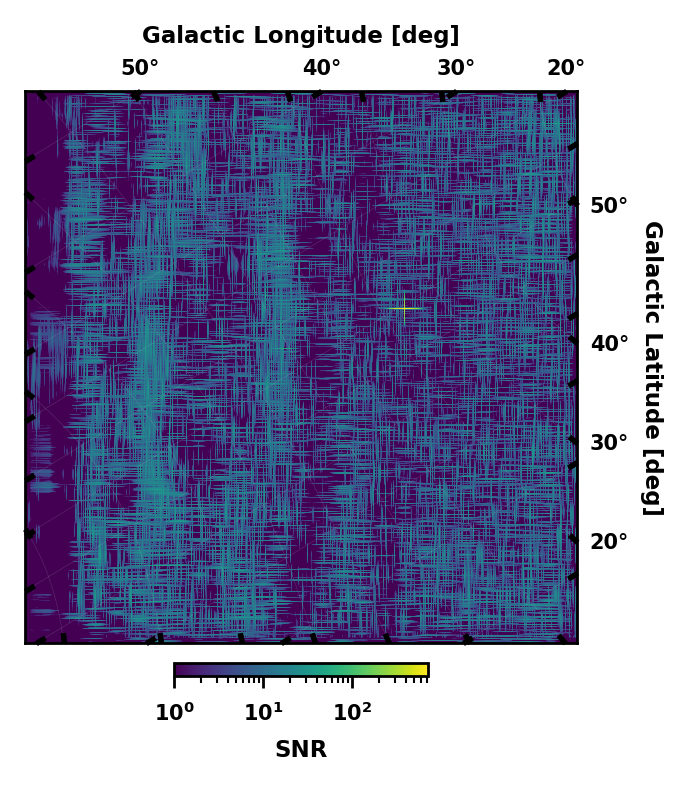

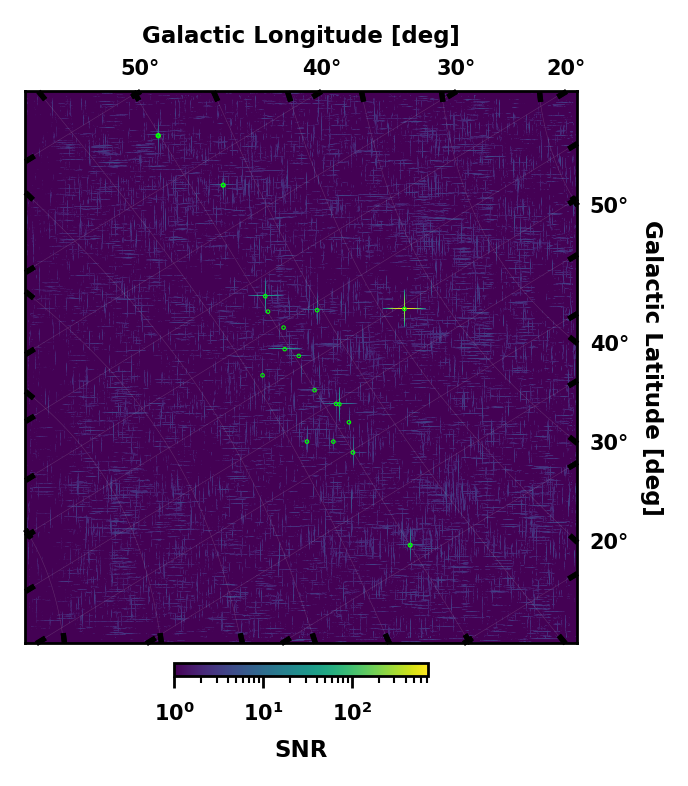

In [ ]:
compIROS_true_path = f"{SAVE_PATH}/COMPOSED_sky_SIMUL_CAM1A_CAM1B.fits"
compIROS_out_path = f"{SAVE_PATH}/COMPOSED_OUTsky_IROS_CAM1A_CAM1B.fits"
reg_file_path = f"{SAVE_PATH}/OUTregionfile_IROS_CAM1B.reg"

true_comp, wcs = mgm.open_ImageHDU(compIROS_true_path, ext=2)
out_comp, _ = mgm.open_ImageHDU(compIROS_out_path, ext=2)
reg = np.array(Regions.read(reg_file_path, format='ds9'))[cu_map.idx_b]

# transf: Callable = lambda x: np.pow(np.clip(x, a_min=0.5, a_max=20), 0.75)
transf: Callable = lambda x: np.clip(x, a_min=1, a_max=None)

KWS_comp = {
    'ticks_spacing': 10,
    'txt_offset': (10, 30),
    'txt_visual': {'textangle': 45, 'color': 'white', 'fontsize': 3},
    'figsize': (3.5, 3.5),
}

show_composed_skymap(
    image=transf(true_comp),
    wcs=wcs,
    save_to=f'{OUT_RESULTS_PATH}/composed_TRUESKY.pdf',
    **KWS_comp,
)
show_composed_skymap(
    image=transf(out_comp),
    wcs=wcs,
    reg=reg,
    save_to=f'{OUT_RESULTS_PATH}/composed_OUTSKY.pdf',
    **KWS_comp,
)

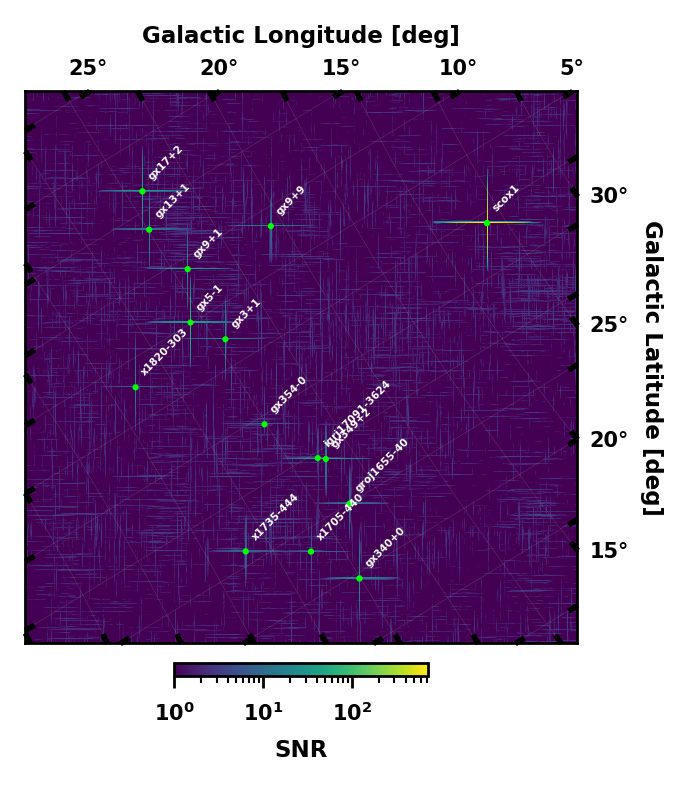

In [30]:
from astropy.nddata import Cutout2D
from astropy.coordinates import SkyCoord

from bloodmoon.coords import angle2shift, shift2equatorial

def angle2equatorial(camera, sdl, theta_x, theta_y) -> tuple[float, float]:
    sx, sy = map(lambda theta: angle2shift(camera, theta), (theta_x, theta_y))
    return shift2equatorial(sdl, camera, sx, sy)

tx, ty = 0.0, 6.0

POS: tuple[float, float] = angle2equatorial(wfm, sdlA, tx, ty)
SIZE: tuple[int, int] = (1350, 1350)
cutout = Cutout2D(transf(out_comp), SkyCoord(ra=POS[0], dec=POS[1], frame='fk5', unit='deg'), SIZE, wcs=wcs)

KWS_comp['ticks_spacing'] = 5
show_composed_skymap(
    image=transf(cutout.data),
    wcs=cutout.wcs,
    reg=reg,
    save_to=f'{OUT_RESULTS_PATH}/composed_OUTSKY_cutout.pdf',
    **KWS_comp,
)

### <center>**Sources Localisation Efficiency**<center>

In [14]:
from darksun.show import DSPlot

def compose(a: NDArray, b: NDArray) -> NDArray:
    return np.sqrt(a ** 2 + b ** 2)

def get_symlimits(arr: NDArray, offset: float | None = None) -> tuple[float, float]:
    """Returns symmetric `arr` boundary centered around abs max value."""
    m = np.abs(arr).max()
    if offset: m += offset
    return -m, m

def plot_crdres(
    crdres_fine_A: NDArray,
    crdres_fine_B: NDArray,
    crdres_coarse_A: NDArray,
    crdres_coarse_B: NDArray,
    snrvals: NDArray,
    save_to: str | Path | None = None,
    **fig_kws,
) -> None:
    """Plots the coordinates residues along fine/coarse directions."""
    PLOTPARAMS = export_pltparams()
    OFFSET = 0.1

    dsp = DSPlot(2, 1)
    fig, axs = dsp.config_subplots(**fig_kws)

    # - FINE DIRECTION (AXS[0])
    pts_fine = axs[0].scatter(crdres_fine_B, crdres_fine_A, c=snrvals, cmap='viridis', norm='log')
    axs[0].set_title(
        label='Coords Residues | Fine Axis', fontsize=PLOTPARAMS['title_fs'],
        pad=PLOTPARAMS['title_pad'], fontweight=PLOTPARAMS['label_fw'],
    )
    axs[0].set_xlabel(
        xlabel='$\\Delta\\theta_{\\text{fine}}^{\\text{B}}$ [arcmin]',
        fontsize=PLOTPARAMS['label_fs'], fontweight=PLOTPARAMS['label_fw'],
    )
    axs[0].set_ylabel(
        ylabel='$\\Delta\\theta_{\\text{fine}}^{\\text{A}}$ [arcmin]',
        fontsize=PLOTPARAMS['label_fs'], fontweight=PLOTPARAMS['label_fw'],
    )
    cbar = fig.colorbar(
        pts_fine, ax=axs[0], location='right', shrink=PLOTPARAMS['cbar_shrink'],
        pad=PLOTPARAMS[f'cbar_pad_right'],
    )
    cbar.ax.tick_params(labelsize=PLOTPARAMS['cbar_ticks_ls'])
    cbar.set_label(
        'SNR', fontsize=PLOTPARAMS['cbar_label_fs'], fontweight=PLOTPARAMS['cbar_label_fw'],
    )
    dsp.config_axlim(axs[0], get_symlimits(crdres_fine_B, offset=OFFSET), get_symlimits(crdres_fine_A, offset=OFFSET))

    # - COARSE DIRECTION (AXS[1])
    pts_coarse = axs[1].scatter(crdres_coarse_B, crdres_coarse_A, c=snrvals, cmap='viridis', norm='log')
    axs[1].set_title(
        label='Coords Residues | Coarse Axis', fontsize=PLOTPARAMS['title_fs'],
        pad=PLOTPARAMS['title_pad'], fontweight=PLOTPARAMS['label_fw'],
    )
    axs[1].set_xlabel(
        xlabel='$\\Delta\\theta_{\\text{coarse}}^{\\text{B}}$ [deg]',
        fontsize=PLOTPARAMS['label_fs'], fontweight=PLOTPARAMS['label_fw'],
    )
    axs[1].set_ylabel(
        ylabel='$\\Delta\\theta_{\\text{coarse}}^{\\text{A}}$ [deg]',
        fontsize=PLOTPARAMS['label_fs'], fontweight=PLOTPARAMS['label_fw'],
    )
    cbar = fig.colorbar(
        pts_coarse, ax=axs[1], location='right', shrink=PLOTPARAMS['cbar_shrink'],
        pad=PLOTPARAMS[f'cbar_pad_right'],
    )
    cbar.ax.tick_params(labelsize=PLOTPARAMS['cbar_ticks_ls'])
    cbar.set_label(
        'SNR', fontsize=PLOTPARAMS['cbar_label_fs'], fontweight=PLOTPARAMS['cbar_label_fw'],
    )
    dsp.config_axlim(axs[1], get_symlimits(crdres_coarse_B, offset=OFFSET), get_symlimits(crdres_coarse_A, offset=OFFSET))

    for ax in axs: dsp.config_ticks(ax)

    if save_to is not None: fig.savefig(save_to)
    plt.show()

    return

Analysing LEMX-CAM1BS1: 100%|██████████| 20/20 [00:00<00:00, 145.09it/s]  


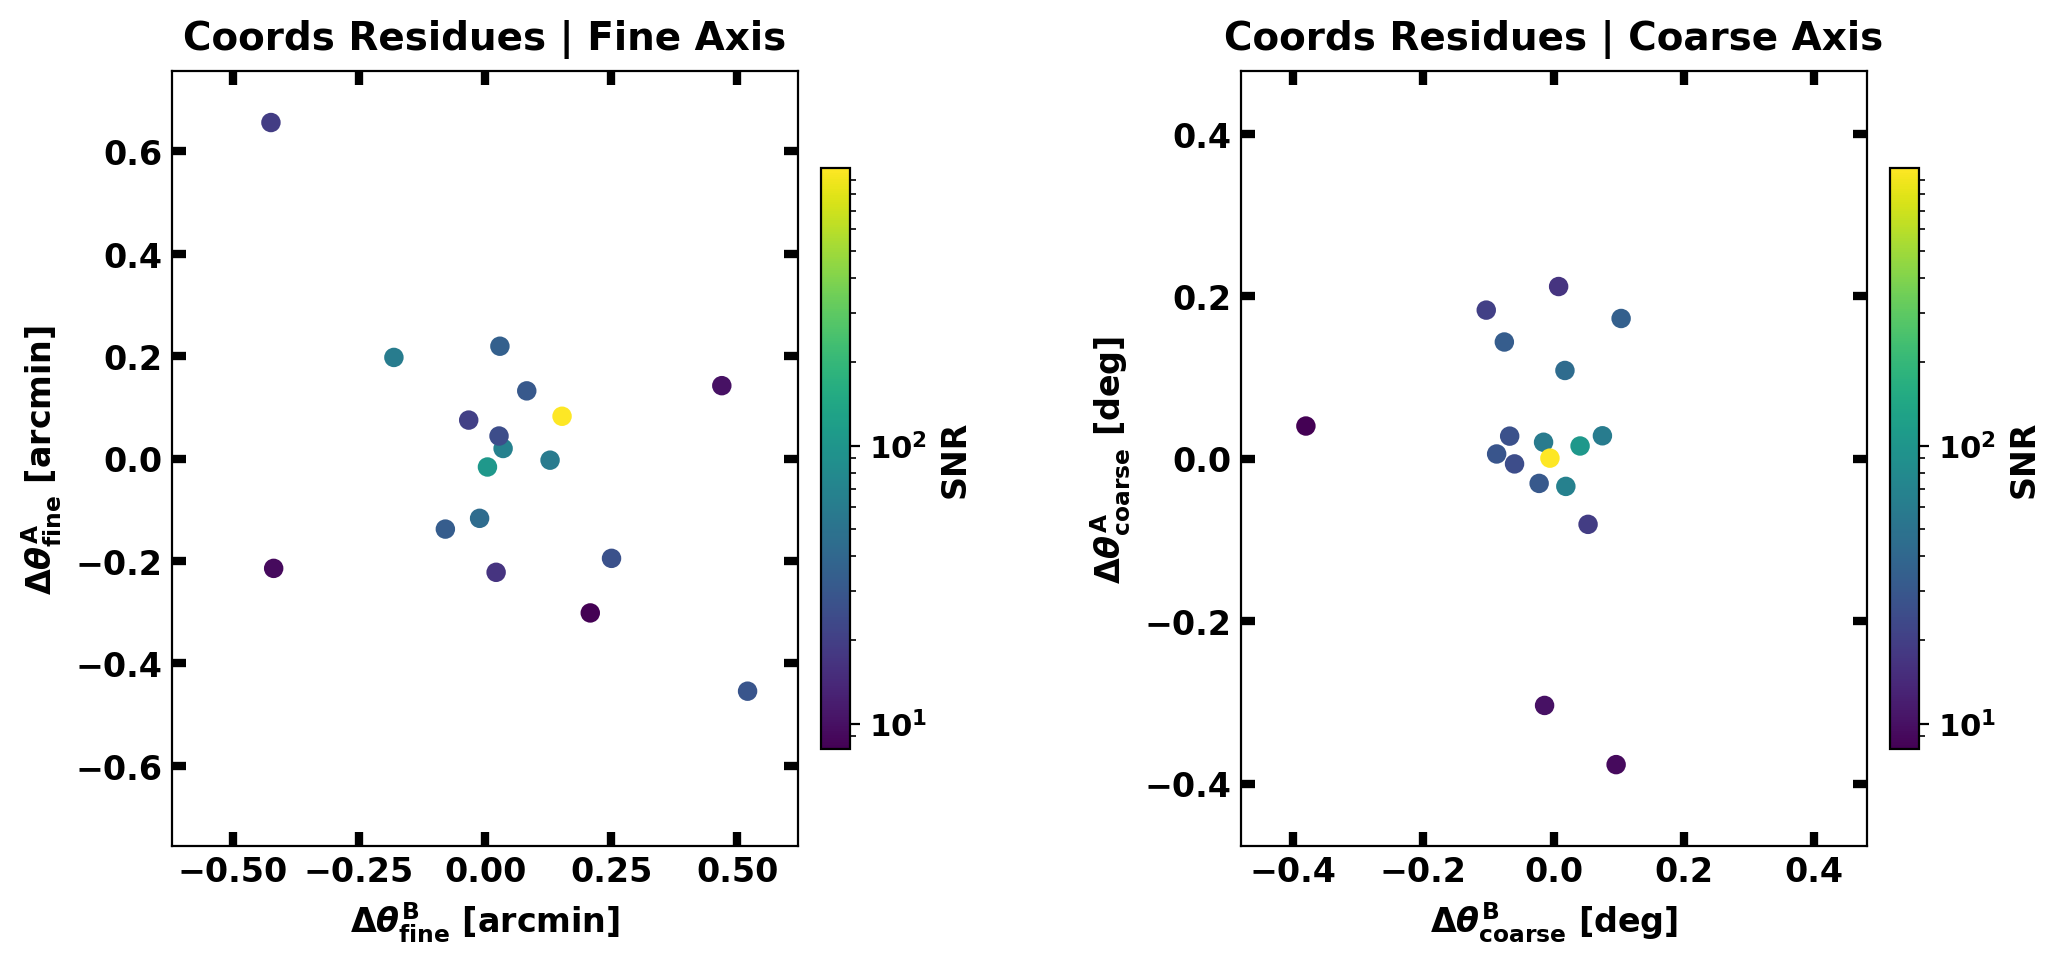

In [20]:
crdres_fine_A, crdres_coarse_A = map(lambda x: x[cu_map.idx_a], mgm.get_angularcoords_residues(logA, catA, sdlA, wfm))
crdres_fine_B, crdres_coarse_B = map(lambda x: x[cu_map.idx_b], mgm.get_angularcoords_residues(logB, catB, sdlB, wfm))

snr = compose(np.array(logA.log['snr'])[cu_map.idx_a], np.array(logB.log['snr'])[cu_map.idx_b])

plot_crdres(
    crdres_fine_A=crdres_fine_A,
    crdres_fine_B=crdres_fine_B,
    crdres_coarse_A=crdres_coarse_A / 60,
    crdres_coarse_B=crdres_coarse_B / 60,
    snrvals=snr,
    save_to=f'{OUT_RESULTS_PATH}/camUnit_src_coords_res.pdf',
    size=4.5,
    wspace=0.4,
)

### <center>**Sources Statistics**<center>

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


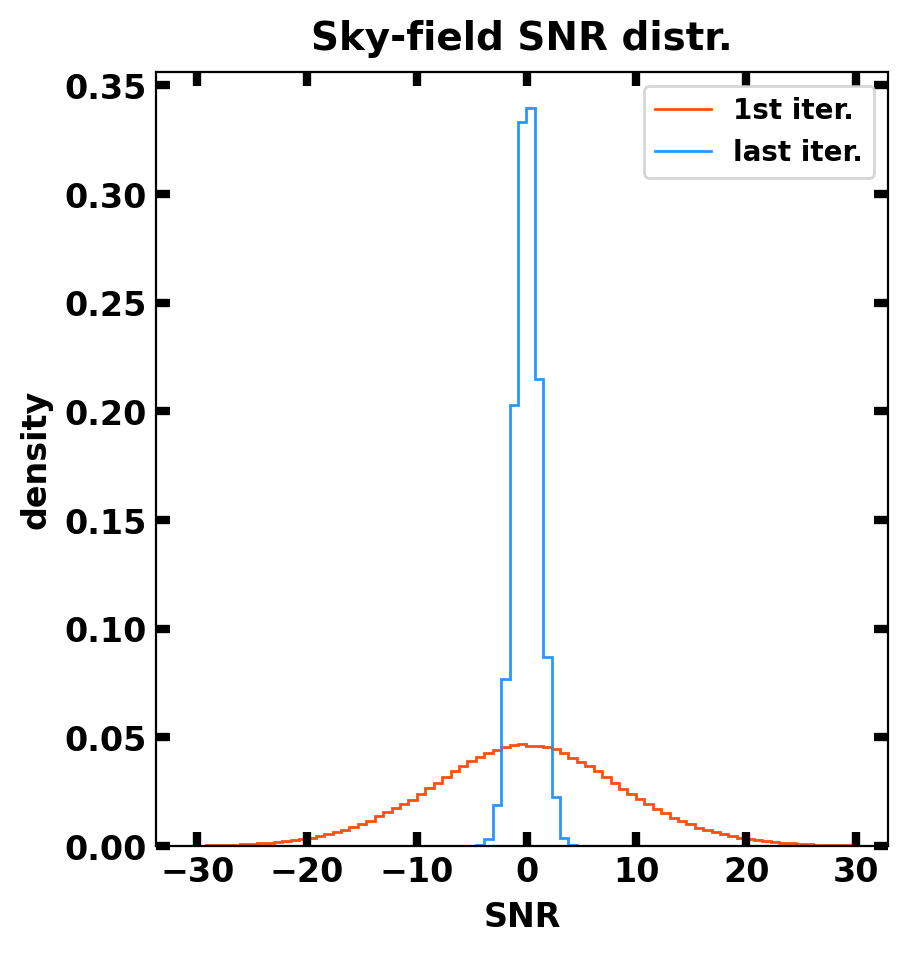

In [21]:
# SNR distr. vs coding noise reduction (true sky --> last IROS iteration)
ycut, xcut = UPS_Y * 30, UPS_X * 20
num_bins = 1000
density = True
distr_lims = (-30, 30)

# - CAMERA A
_, true_skysnr = ds.load_sky(f'{SAVE_PATH}/sky_SIMUL_CAM1A.fits')
_, res_skysnr = ds.load_sky(f'{SAVE_PATH}/skyRES_IROS_CAM1A.fits')

true_skysnr = ds.unframe(true_skysnr, ycut, xcut)
res_skysnr = ds.unframe(res_skysnr, ycut, xcut)

hist_true_skysnr, bins = np.histogram(true_skysnr, bins=num_bins, density=density)
hist_res_skysnr, _ = np.histogram(res_skysnr, bins=bins, density=density)
bins_slice, hist_slice = ds.config_distr_limits(bins, *distr_lims)

dmapA_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_res_skysnr[hist_slice]),
    title=f'Sky-field SNR distr.',
    xlabel='SNR',
    ylabel='density',
    labels=('1st iter.', 'last iter.'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'DodgerBlue'),
)

# # - CAMERA B
# _, true_skysnr = ds.load_sky(f'{SAVE_PATH}/sky_SIMUL_CAM1B.fits')
# _, res_skysnr = ds.load_sky(f'{SAVE_PATH}/skyRES_IROS_CAM1B.fits')

# true_skysnr = ds.unframe(true_skysnr, ycut, xcut)
# res_skysnr = ds.unframe(res_skysnr, ycut, xcut)

# hist_true_skysnr, bins = np.histogram(true_skysnr, bins=num_bins, density=density)
# hist_res_skysnr, _ = np.histogram(res_skysnr, bins=bins, density=density)
# bins_slice, hist_slice = ds.config_distr_limits(bins, *distr_lims)

# dmapB_snr = ds.map4plot(
#     arrs=(hist_true_skysnr[hist_slice], hist_res_skysnr[hist_slice]),
#     title=f'Significance distr. | CAM B',
#     xlabel='SNR',
#     ylabel='density',
#     labels=('1st iter.', 'last iter.'),
#     x=bins[bins_slice],
#     style='stairs',
#     color=('OrangeRed', 'DodgerBlue'),
# )

# - PLOT

ds.plot(
    dmaps=dmapA_snr,
    save_to=f'{OUT_RESULTS_PATH}/snr_distr_vs_codnoise.pdf',
    figsize=(4.5, 4.5),
)

In [23]:
from scipy.optimize import curve_fit

def Gaussian(x: NDArray, x0: float = 0.0, sigma: float = 1.0) -> NDArray:
    """Returns a 1D Gaussian distribution centered around `x0` and with std `sigma`."""
    return (
        1.0 / np.sqrt(2 * np.pi * np.square(sigma)) * np.exp(-np.square(x - x0) / (2 * np.square(sigma)))
    )

center_bins = 0.5 * (bins[:-1] + bins[1:])

popt_start, _ = curve_fit(Gaussian, xdata=center_bins, ydata=hist_true_skysnr, p0=[0, 1.0])
popt_end, pcov_end = curve_fit(Gaussian, xdata=center_bins, ydata=hist_res_skysnr, p0=[0, 1.0])

print(
    f'Start (mu, sigma): {popt_start}\n'
    f'Final (mu, sigma): {popt_end} +/- {np.sqrt(np.diag(pcov_end))}\n'
)

Start (mu, sigma): [-0.05493976  8.5843393 ]
Final (mu, sigma): [0.00301834 1.11854362] +/- [0.00023826 0.00019454]



### <center>**Estimate Weaker Source**<center>

In [ ]:
from numpy.typing import NDArray

from bloodmoon.coords import equatorial2shift
from darksun.benchmarking import source_catalogue_data
from darksun.data import Log, DataLoader, CatalogueLoader
from darksun.analyze import get_effective_area

def find_weaker_src(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    idx_map: NDArray | None = None,
) -> tuple[str, int]:
    """Finds the weaker detected source during the IROS sky reconstruction."""
    true_cts = mgm.extract_catalogue_fluences(log, catalogue, sdl, camera)
    ids, cts = map(lambda x: x[idx_map], (np.array(logA.log['ID']), true_cts))
    src = str(ids[int(np.argmin(cts))])
    return src, int(cts.min())

def compute_src_flx(
    sourceID: str,
    cts: int,
    camera: CodedMaskCamera,
    sdl: DataLoader,
    catalogue: CatalogueLoader
) -> float:
    """Computes the instrumental flux of given source."""
    data = source_catalogue_data(sourceID, catalogue.DLdata)
    sx, sy = equatorial2shift(sdl, camera, data['RA'], data['DEC'])
    eff_area = get_effective_area(camera, sx, sy)
    exposure = sdl.header['EXPOSURE']
    return float(cts / eff_area / exposure)


src, cts = find_weaker_src(logA, catA, sdlA, wfm, cu_map.idx_a)
flx = compute_src_flx(src, cts, wfm, sdlA, catA)

Analysing GX349+2:  10%|▉         | 2/21 [00:00<00:07,  2.51it/s]

## USING BULK MASK with 1.5 mm cover ##


Analysing LEMX-CAM1AS3: 100%|██████████| 21/21 [00:02<00:00,  7.98it/s]  


In [8]:
src, cts, flx / 10

('serx1', 6974, 0.23580977516892393)

In [14]:
flx = compute_src_flx('serx1', 7842, wfm, sdlB, catB)

'serx1', 7842, flx / 10

('serx1', 7842, 0.23801930039061941)

In [ ]:
def comp_combflx() -> float:
    ctsA, ctsB = 6974, 7842
    data = source_catalogue_data('serx1', catA.DLdata)
    sx, sy = equatorial2shift(sdlA, wfm, data['RA'], data['DEC'])
    eff_area = get_effective_area(wfm, sx, sy) + get_effective_area(wfm, sy, -sx)
    return (ctsA + ctsB) / eff_area / 1e3

comp_combflx() / 2.7 * (5 / 9.1) * np.sqrt(1e3)

np.float64(1.524985719150381)

In [ ]:
# ds.plot(
#     dmaps=(
#         ds.map4plot(
#             arrs=crdres_fine_A,
#             title='Coords Residues | Fine Directions',
#             x=crdres_fine_B,
#             ylabel='$\\Delta\\theta_{\\text{fine}}^{\\text{B}}$ [arcmin]',
#             xlabel='$\\Delta\\theta_{\\text{fine}}^{\\text{A}}$ [arcmin]',
#             style='scatter',
#             ylim=get_symlimits(crdres_fine_A),
#             xlim=get_symlimits(crdres_fine_B),
#         ),
#     ),
#     figsize=(4.5, 4.5),
#     save_to=f'{OUT_RESULTS_PATH}/camUnit_src_coords_res.pdf',
# )

# ds.plot(
#     dmaps=(
#         ds.map4plot(
#             arrs=crdres_fine_A,
#             title='Coords Residues | Fine Directions',
#             x=crdres_fine_B,
#             ylabel='$\\Delta\\theta_{\\text{fine}}^{\\text{B}}$ [arcmin]',
#             xlabel='$\\Delta\\theta_{\\text{fine}}^{\\text{A}}$ [arcmin]',
#             style='scatter',
#             ylim=get_symlimits(crdres_fine_A),
#             xlim=get_symlimits(crdres_fine_B),
#         ),
#         ds.map4plot(
#             arrs=crdres_coarse_A,
#             title='Coords Residues | Coarse Directions',
#             x=crdres_coarse_B,
#             ylabel='$\\Delta\\theta_{\\text{coarse}}^{\\text{B}}$ [arcmin]',
#             xlabel='$\\Delta\\theta_{\\text{coarse}}^{\\text{A}}$ [arcmin]',
#             style='scatter',
#             ylim=get_symlimits(crdres_coarse_A),
#             xlim=get_symlimits(crdres_coarse_B),
#         ),
#     ),
#     ncols=2,
#     figsize=(9.5, 4.0),
#     wspace=0.4,
#     save_to=f'{OUT_RESULTS_PATH}/camUnit_src_coords_res.pdf',
# )